  # Lab 5: Non-linearities and Regularisation

In this lab, you will explore different methods for regularising neural networks to reduce overfitting and improve generalisation. This lab uses the material covered in the fourth and fifth lecture slides.

**Learning Objectives:**
- Understand and implement L1 and L2 regularisation penalties
- Train models with different regularisation schemes and compare their effects
- Implement and apply data augmentation techniques
- Analyse the impact of regularisation on model parameters and performance
- Explore regularisation methods in both custom implementations and PyTorch

# Exercise 1: L1 and L2 Penalties

In the previous lab notebook, we explored the issue of overfitting. This arises when the model is 'too complex' (i.e., has too many degrees of freedom/parameters) for the amount of available data.

One method for reducing overfitting is to decrease the model's flexibility. We can do this by simply reducing the number of free parameters (e.g., using fewer layers or smaller layer dimensions). However, we might want a more continuous way of varying the effective flexibility of a model with a fixed architecture.

## Regularisation Theory

A common approach is to add an additional term to the objective function that penalises some measure of model complexity as a function of the model parameters. The training objective becomes minimising the sum $E^\star$ of the data-driven error term $\bar{E}$ and a model complexity term $C$:

$$E^\star = \underbrace{\bar{E}}_{\text{data term}} + \underbrace{C}_{\text{complexity term}}$$

The complexity term $C$ must be easy to compute and differentiable with respect to the model parameters. A common choice is to use terms involving the **norms** (a measure of size) of the parameters, which penalises models with large parameter values.

### L1 and L2 Norms

For a $D$-dimensional vector $\mathbf{v}$, the **L1 norm** is:
$$\| \boldsymbol{v} \|_1 = \sum_{d=1}^D \left| v_d \right|$$

The **L2 norm** is:
$$\| \boldsymbol{v} \|_2 = \left[ \sum_{d=1}^D \left( v_d^2 \right) \right]^{\frac{1}{2}}$$

For a $K \times D$ matrix $\mathbf{M}$, we define norms by collapsing the matrix to a vector $\boldsymbol{m} = \mathrm{vec}[\mathbf{M}] = [ M_{1,1} \dots M_{1,D} \; M_{2,1} \dots M_{K,D} ]^{\rm T}$ and taking the norm of this resulting vector.

### Penalty Terms

The overall complexity penalty term $C$ is defined as a sum over individual complexity terms for each of the $P$ parameters of the model:
$$C = \sum_{i=1}^P C^{(i)}$$

Some per-parameter penalty terms $C^{(i)}$ may be set to zero if we don't wish to penalise the corresponding parameter.

We introduce positive scalar coefficients $\beta_i$ to control the trade-off between model complexity and data error terms.

**L1 penalty** on the $i$-th vector parameter $\boldsymbol{p}^{(i)}$:
$$C^{(i)}_{\text{L1}} = \beta_i \left\| \boldsymbol{p}^{(i)} \right\|_1 = \beta_i \sum_{d=1}^D \left| p^{(i)}_d \right|$$

with gradient:
$$\frac{\partial C^{(i)}_{\text{L1}}}{\partial p^{(i)}_d} = \beta_i \, \text{sgn}\left( p^{(i)}_d \right)$$

where $\text{sgn}(u) = +1$ if $u > 0$, $\text{sgn}(u) = -1$ if $u < 0$, and $\text{sgn}(0) = 0$ by convention.

**L2 penalty** on the $i$-th vector parameter $\boldsymbol{p}^{(i)}$:
$$C^{(i)}_{\text{L2}} = \frac{1}{2} \beta_i \left\| \boldsymbol{p}^{(i)} \right\|_2^2 = \frac{1}{2} \beta_i \sum_{d=1}^D \left[ \left( p^{(i)}_d \right)^2 \right]$$

with gradient:
$$\frac{\partial C^{(i)}_{\text{L2}}}{\partial p^{(i)}_d} = \beta_i p^{(i)}_d$$

Note: This is proportional to the square of the L2 norm rather than the L2 norm itself, but it's universally called an L2 penalty. The $\frac{1}{2}$ factor cancels when calculating the gradient.

---

## 🎯 **Your Tasks:**

Use the above definitions to implement the `__call__` and `grad` methods for the skeleton `L1Penalty` and `L2Penalty` classes below:

1. **`__call__` method**: Calculate the penalty value for a given parameter
2. **`grad` method**: Calculate the penalty gradient with respect to the parameter

**Requirements:**
- Use the `coefficient` property as the $\beta_i$ value in the equations above
- Your implementations should handle both 1D (vector) and 2D (matrix) NumPy arrays
- The gradient should return an array of the same shape as the input parameter

**Hint:** Use NumPy functions like `np.abs()`, `np.sum()`, and `np.sign()` for efficient implementation.

In [1]:
import numpy as np
seed = 22102017 
rng = np.random.RandomState(seed)

class L1Penalty(object):
    """L1 parameter penalty.
    
    Term to add to the objective function penalising parameters
    based on their L1 norm.
    """
    
    def __init__(self, coefficient):
        """Create a new L1 penalty object.
        
        Args:
            coefficient: Positive constant to scale penalty term by.
        """
        assert coefficient > 0., 'Penalty coefficient must be positive.'
        self.coefficient = coefficient
        
    def __call__(self, parameter):
        """Calculate L1 penalty value for a parameter.
        
        Args:
            parameter: Array corresponding to a model parameter.
            
        Returns:
            Value of penalty term.
        """
        return np.sum(self.coefficient * np.abs(parameter))
        
    def grad(self, parameter):
        """Calculate the penalty gradient with respect to the parameter.
        
        Args:
            parameter: Array corresponding to a model parameter.
            
        Returns:
            Value of penalty gradient with respect to parameter. This
            should be an array of the same shape as the parameter.
        """
        return self.coefficient * np.sign(parameter)
    
    def __repr__(self):
        return 'L1Penalty({0})'.format(self.coefficient)


class L2Penalty(object):
    """L2 parameter penalty.
    
    Term to add to the objective function penalising parameters
    based on their L2 norm squared.
    """

    def __init__(self, coefficient):
        """Create a new L2 penalty object.
        
        Args:
            coefficient: Positive constant to scale penalty term by.
        """
        assert coefficient > 0., 'Penalty coefficient must be positive.'
        self.coefficient = coefficient
        
    def __call__(self, parameter):
        """Calculate L2 penalty value for a parameter.
        
        Args:
            parameter: Array corresponding to a model parameter.
            
        Returns:
            Value of penalty term.
        """
        return 0.5 * self.coefficient * np.sum(parameter ** 2)
        
    def grad(self, parameter):
        """Calculate the penalty gradient with respect to the parameter.
        
        Args:
            parameter: Array corresponding to a model parameter.
            
        Returns:
            Value of penalty gradient with respect to parameter. This
            should be an array of the same shape as the parameter.
        """
        return self.coefficient * parameter 
    
    def __repr__(self):
        return 'L2Penalty({0})'.format(self.coefficient)

## Testing Your Implementation

Test your implementations by running the cells below. These tests verify that both the penalty values and gradients are calculated correctly.

In [2]:
test_params_1 = np.array([[0.5, 0.3, -1.2, 5.8], [0.2, -3.1, 4.9, -5.0]])
test_params_2 = np.array([0.8, -0.6, -0.3, 1.5, 2.8])
true_l1_cost_1 = 10.5
true_l1_grad_1 = np.array([[0.5, 0.5, -0.5, 0.5], [0.5, -0.5, 0.5, -0.5]])
true_l1_cost_2 = 3.
true_l1_grad_2 = np.array([0.5, -0.5, -0.5, 0.5, 0.5])
l1 = L1Penalty(0.5)
if (not np.allclose(l1(test_params_1), true_l1_cost_1) or
        not np.allclose(l1(test_params_2), true_l1_cost_2)):
    print('L1Penalty.__call__ giving incorrect value(s).')
elif (not np.allclose(l1.grad(test_params_1), true_l1_grad_1) or 
          not np.allclose(l1.grad(test_params_2), true_l1_grad_2)):
    print('L1Penalty.grad giving incorrect value(s).')
else:
    print('All test values calculated correctly for L1Penalty')

All test values calculated correctly for L1Penalty


In [3]:
test_params_1 = np.array([[0.5, 0.3, -1.2, 5.8], [0.2, -3.1, 4.9, -5.0]])
test_params_2 = np.array([0.8, -0.6, -0.3, 1.5, 2.8])
true_l2_cost_1 = 23.52
true_l2_grad_1 = np.array([[0.25, 0.15, -0.6, 2.9], [0.1, -1.55, 2.45, -2.5]])
true_l2_cost_2 = 2.795
true_l2_grad_2 = np.array([0.4, -0.3, -0.15, 0.75, 1.4])
l2 = L2Penalty(0.5)
if (not np.allclose(l2(test_params_1), true_l2_cost_1) or
        not np.allclose(l2(test_params_2), true_l2_cost_2)):
    print('L2Penalty.__call__ giving incorrect value(s).')
elif (not np.allclose(l2.grad(test_params_1), true_l2_grad_1) or 
          not np.allclose(l2.grad(test_params_2), true_l2_grad_2)):
    print('L2Penalty.grad giving incorrect value(s).')
else:
    print('All test values calculated correctly for L2Penalty')

All test values calculated correctly for L2Penalty


# Exercise 2: Training with Regularisation

## Background: Incorporating Regularisation into Training

Previously in Lab 2, you implemented a `grads_wrt_params` function to calculate the gradient of an error function with respect to model parameters, given gradients of the error function with respect to model outputs.

When training with a regularised objective function, we must additionally calculate the gradients of the regularisation penalty terms and add them to the error function gradient terms. From the regularised objective $E^\star$, the gradient with respect to the $d$-th element of the $i$-th model parameter is:

$$\frac{\partial E^\star}{\partial p^{(i)}_d} = \frac{\partial \bar{E}}{\partial p^{(i)}_d} + \frac{\partial C}{\partial p^{(i)}_d}$$

Since the model complexity term is a sum of per-parameter terms and only one depends on the $i$-th parameter:
$$\frac{\partial C}{\partial p^{(i)}_d} = \frac{\partial C^{(i)}}{\partial p^{(i)}_d}$$

This corresponds to the penalty term gradients you implemented above.

## Implementation Details

The `AffineLayer` class has been modified to accept penalty terms on weight matrices and bias vectors. The penalty terms are specified using:
- `weights_penalty`: Penalty for weight parameters
- `biases_penalty`: Penalty for bias parameters  

If either is set to `None` (default), no regularisation is applied to that parameter. It's common to only regularise weight parameters.

---

## 🎯 **Your Tasks:**

Train MNIST digit classification models using the `L1Penalty` and `L2Penalty` classes with the following regularisation schemes:

### Model Architecture
- **3 affine layers** with `ReluLayer` activations between them
- **Hidden layer dimensions**: 100 units each
- **Output layer**: `AffineLayer` (outputs log probabilities)
- **Error function**: `CrossEntropySoftmaxError`

### Weight Initialisation
- **Weights**: `GlorotUniformInit` with gain=0.5 (adjusted for ReLU)
- **Biases**: `ConstantInit(0.)`

### Regularisation Schemes to Compare
1. **No regularisation** (baseline)
2. **L1 penalty** with coefficient $10^{-5}$ on all weight matrices
3. **L1 penalty** with coefficient $10^{-3}$ on all weight matrices  
4. **L2 penalty** with coefficient $10^{-4}$ on all weight matrices
5. **L2 penalty** with coefficient $10^{-2}$ on all weight matrices

### Expected Output
For each regularisation scheme, store:
- Training statistics (from `Optimiser.train`)
- Final values of the first layer weights

### Example Model Creation
```python
weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, 
                biases_init, weights_penalty=weights_penalty),
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, 
                biases_init, weights_penalty=weights_penalty),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, 
                biases_init, weights_penalty=weights_penalty)
])
error = CrossEntropySoftmaxError()
```

**Note:** Set `weights_penalty` to the appropriate penalty object for each experiment.

In [4]:
#TODO Train the model with L1 and L2 penalties

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import logging

import os
os.environ['MLP_DATA_DIR'] = r"C:\Users\samue\mlpractical\data"

# Import MLP framework components
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer
from mlp.errors import CrossEntropyError, CrossEntropySoftmaxError
from mlp.models import SingleLayerModel, MultipleLayerModel
from mlp.initialisers import UniformInit, GlorotUniformInit, ConstantInit
from mlp.learning_rules import GradientDescentLearningRule
from mlp.data_providers import MNISTDataProvider
from mlp.optimisers import Optimiser

# Set plot style
plt.style.use('ggplot')

# Seed a random number generator for reproducibility
seed = 6102016 
rng = np.random.RandomState(seed)

# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST dataset
train_data = MNISTDataProvider('train', rng=rng)
valid_data = MNISTDataProvider('valid', rng=rng)

# Set input and output dimensions for MNIST
input_dim, output_dim = 784, 10 

In [5]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')


    return stats, keys, run_time

In [6]:
# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = MNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = MNISTDataProvider('valid', batch_size=batch_size, rng=rng)

Epoch 5: 0.7s to complete
    error(train)=2.18e+00, acc(train)=5.37e-01, error(valid)=2.18e+00, acc(valid)=5.58e-01
Epoch 10: 0.6s to complete
    error(train)=1.73e+00, acc(train)=6.55e-01, error(valid)=1.71e+00, acc(valid)=6.79e-01
Epoch 15: 0.7s to complete
    error(train)=1.07e+00, acc(train)=7.46e-01, error(valid)=1.04e+00, acc(valid)=7.68e-01
Epoch 20: 0.7s to complete
    error(train)=7.51e-01, acc(train)=8.09e-01, error(valid)=7.15e-01, acc(valid)=8.30e-01
Epoch 25: 0.7s to complete
    error(train)=6.00e-01, acc(train)=8.40e-01, error(valid)=5.62e-01, acc(valid)=8.58e-01
Epoch 30: 0.7s to complete
    error(train)=5.18e-01, acc(train)=8.61e-01, error(valid)=4.81e-01, acc(valid)=8.77e-01
Epoch 35: 0.6s to complete
    error(train)=4.67e-01, acc(train)=8.73e-01, error(valid)=4.32e-01, acc(valid)=8.86e-01
Epoch 40: 0.6s to complete
    error(train)=4.33e-01, acc(train)=8.81e-01, error(valid)=4.00e-01, acc(valid)=8.93e-01
Epoch 45: 0.6s to complete
    error(train)=4.08e-01, acc

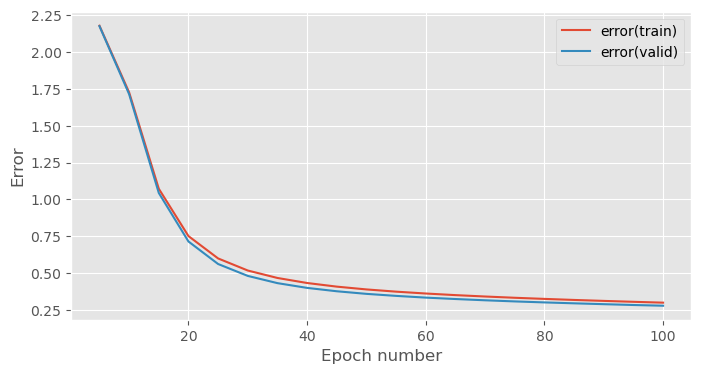

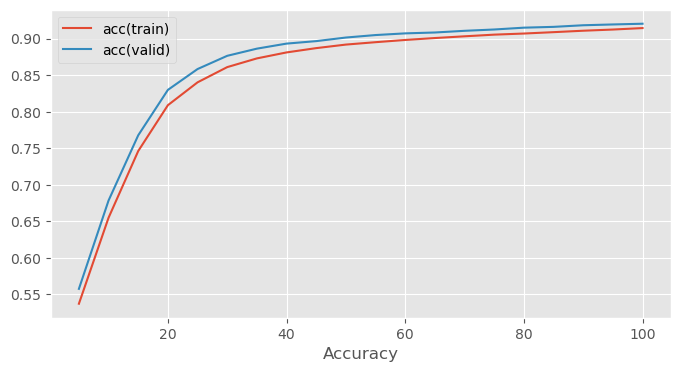

In [15]:
#experiment 1: no regularisation 

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5

weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval)[0]


layer_weights = model.layers[0].weights

Epoch 5: 1.6s to complete
    error(train)=2.19e+00, acc(train)=6.04e-01, error(valid)=2.19e+00, acc(valid)=6.22e-01
Epoch 10: 1.9s to complete
    error(train)=1.75e+00, acc(train)=6.44e-01, error(valid)=1.74e+00, acc(valid)=6.59e-01
Epoch 15: 1.5s to complete
    error(train)=1.07e+00, acc(train)=7.63e-01, error(valid)=1.03e+00, acc(valid)=7.87e-01
Epoch 20: 1.7s to complete
    error(train)=7.39e-01, acc(train)=8.15e-01, error(valid)=6.99e-01, acc(valid)=8.35e-01
Epoch 25: 1.2s to complete
    error(train)=5.94e-01, acc(train)=8.45e-01, error(valid)=5.53e-01, acc(valid)=8.62e-01
Epoch 30: 2.1s to complete
    error(train)=5.14e-01, acc(train)=8.62e-01, error(valid)=4.75e-01, acc(valid)=8.78e-01
Epoch 35: 1.4s to complete
    error(train)=4.64e-01, acc(train)=8.75e-01, error(valid)=4.27e-01, acc(valid)=8.88e-01
Epoch 40: 1.7s to complete
    error(train)=4.30e-01, acc(train)=8.82e-01, error(valid)=3.95e-01, acc(valid)=8.95e-01
Epoch 45: 1.3s to complete
    error(train)=4.05e-01, acc

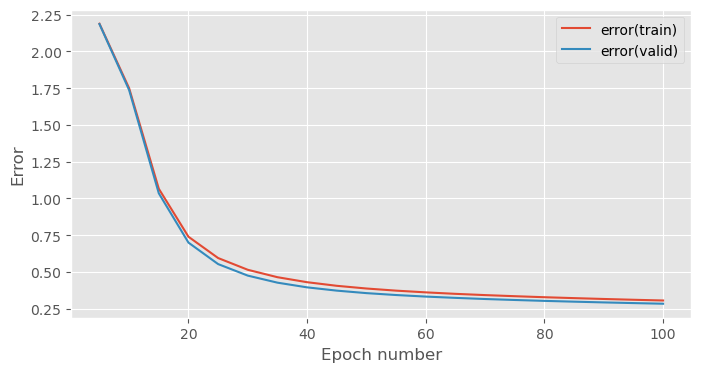

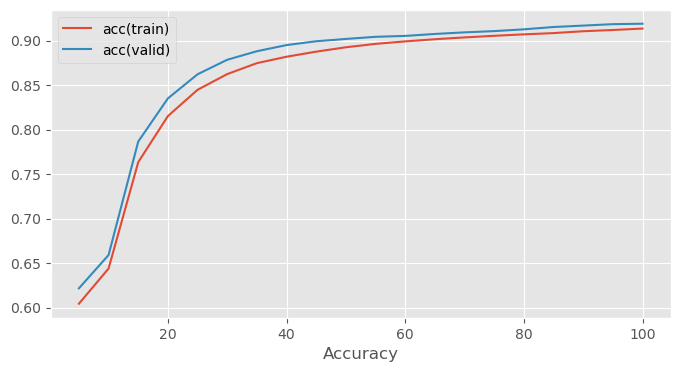

In [16]:
#experiment 2: L1 Penalty with 10^-5 coeffcient 

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5

weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

weights_coefficient = 0.0001
weights_penalty = L1Penalty(weights_coefficient)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=weights_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats2 = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval)[0]

layer_weights2 = model.layers[0].weights.shape

Epoch 5: 3.2s to complete
    error(train)=2.29e+00, acc(train)=2.06e-01, error(valid)=2.29e+00, acc(valid)=1.99e-01
Epoch 10: 3.3s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 15: 3.4s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 20: 2.2s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 25: 3.0s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 30: 2.8s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 35: 2.8s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 40: 2.3s to complete
    error(train)=2.30e+00, acc(train)=1.14e-01, error(valid)=2.30e+00, acc(valid)=1.06e-01
Epoch 45: 3.2s to complete
    error(train)=2.30e+00, acc

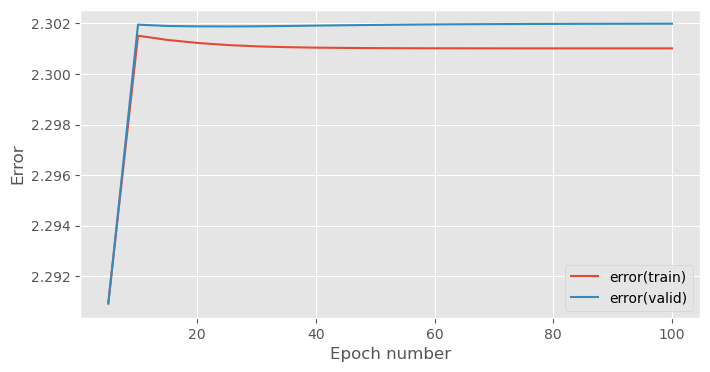

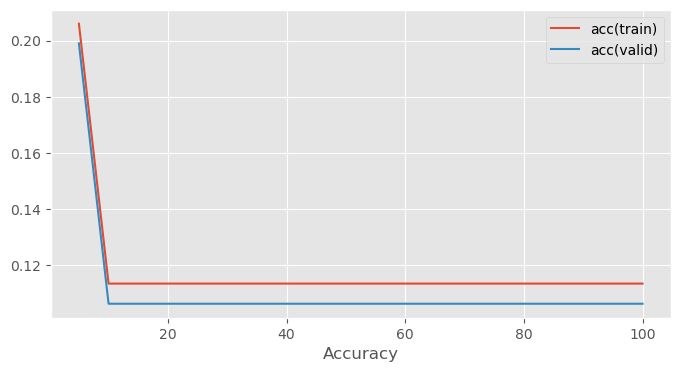

In [17]:
#experiment 3: L1 Penalty with 10^-3 coeffcient 

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5

weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

weights_coefficient = 0.01
weights_penalty = L1Penalty(weights_coefficient)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=weights_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats3 = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval)[0]

layer_weights3 = model.layers[0].weights.shape

Epoch 5: 1.8s to complete
    error(train)=2.21e+00, acc(train)=6.02e-01, error(valid)=2.21e+00, acc(valid)=6.21e-01
Epoch 10: 1.4s to complete
    error(train)=1.82e+00, acc(train)=6.65e-01, error(valid)=1.81e+00, acc(valid)=6.83e-01
Epoch 15: 1.5s to complete
    error(train)=1.16e+00, acc(train)=7.69e-01, error(valid)=1.13e+00, acc(valid)=7.91e-01
Epoch 20: 1.4s to complete
    error(train)=7.59e-01, acc(train)=8.21e-01, error(valid)=7.21e-01, acc(valid)=8.44e-01
Epoch 25: 2.2s to complete
    error(train)=5.90e-01, acc(train)=8.48e-01, error(valid)=5.50e-01, acc(valid)=8.66e-01
Epoch 30: 1.4s to complete
    error(train)=5.06e-01, acc(train)=8.64e-01, error(valid)=4.67e-01, acc(valid)=8.79e-01
Epoch 35: 1.5s to complete
    error(train)=4.55e-01, acc(train)=8.74e-01, error(valid)=4.19e-01, acc(valid)=8.90e-01
Epoch 40: 1.4s to complete
    error(train)=4.22e-01, acc(train)=8.82e-01, error(valid)=3.87e-01, acc(valid)=8.96e-01
Epoch 45: 1.3s to complete
    error(train)=3.99e-01, acc

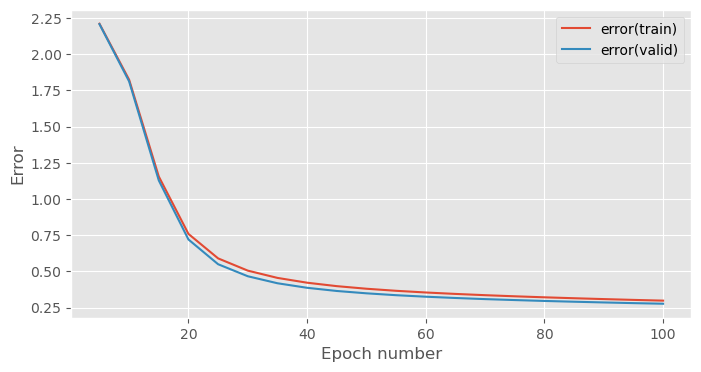

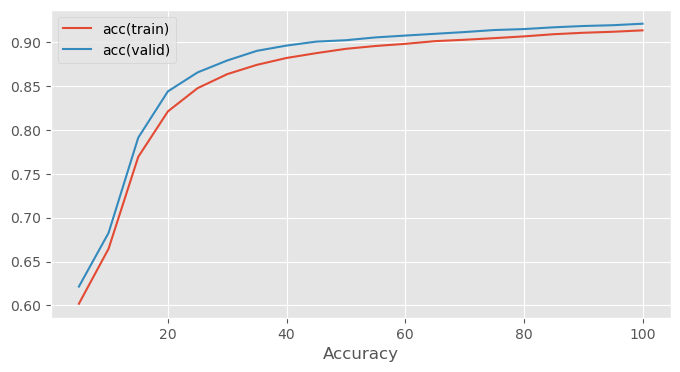

In [19]:
#experiment 4: L1 Penalty with 10^-5 coeffcient 

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5

weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

weights_coefficient = 0.0001
weights_penalty = L2Penalty(weights_coefficient)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=weights_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats4 = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval)[0]

layer_weights4 = model.layers[0].weights.shape

Epoch 5: 1.3s to complete
    error(train)=2.21e+00, acc(train)=2.55e-01, error(valid)=2.21e+00, acc(valid)=2.56e-01
Epoch 10: 1.9s to complete
    error(train)=1.91e+00, acc(train)=5.41e-01, error(valid)=1.90e+00, acc(valid)=5.60e-01
Epoch 15: 1.2s to complete
    error(train)=1.25e+00, acc(train)=7.55e-01, error(valid)=1.23e+00, acc(valid)=7.76e-01
Epoch 20: 1.2s to complete
    error(train)=8.20e-01, acc(train)=8.10e-01, error(valid)=7.84e-01, acc(valid)=8.27e-01
Epoch 25: 1.3s to complete
    error(train)=6.46e-01, acc(train)=8.36e-01, error(valid)=6.07e-01, acc(valid)=8.51e-01
Epoch 30: 1.3s to complete
    error(train)=5.62e-01, acc(train)=8.54e-01, error(valid)=5.23e-01, acc(valid)=8.66e-01
Epoch 35: 1.6s to complete
    error(train)=5.11e-01, acc(train)=8.65e-01, error(valid)=4.75e-01, acc(valid)=8.77e-01
Epoch 40: 1.6s to complete
    error(train)=4.77e-01, acc(train)=8.74e-01, error(valid)=4.43e-01, acc(valid)=8.84e-01
Epoch 45: 1.2s to complete
    error(train)=4.53e-01, acc

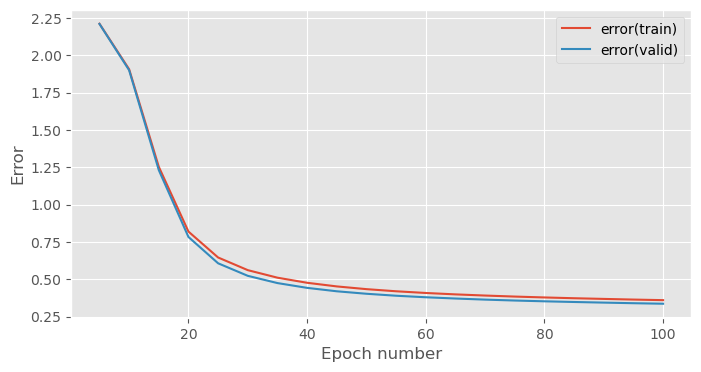

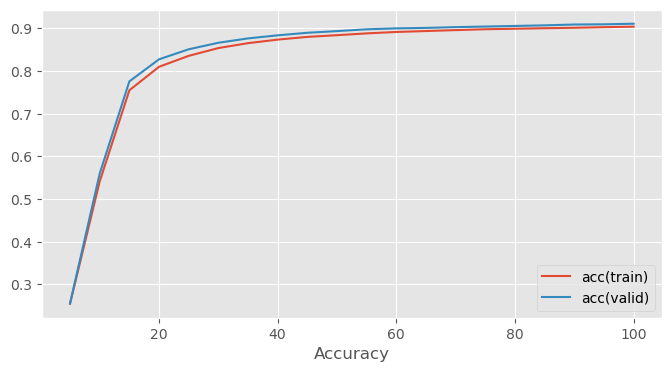

In [20]:
#experiment 5: L2 Penalty with 10^-3 coeffcient 

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 5

weights_init = GlorotUniformInit(0.5, rng)
biases_init = ConstantInit(0.)
input_dim, output_dim, hidden_dim = 784, 10, 100

weights_coefficient = 0.01
weights_penalty = L2Penalty(weights_coefficient)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init, weights_penalty=weights_penalty), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init, weights_penalty=weights_penalty) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = GradientDescentLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats5 = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval)[0]

layer_weights5 = model.layers[0].weights.shape

## 📊 **Analysis Task:**

Create two plots to compare the different regularisation schemes:

1. **Training set error** vs epoch number for all regularisation schemes on the same axis
2. **Validation set error** vs epoch number for all regularisation schemes on the same axis

**Questions to consider:**
- Which regularisation schemes help reduce overfitting?
- How do different penalty coefficients affect convergence?
- What's the trade-off between training and validation error?

Interpret and comment on what you observe in your plots.

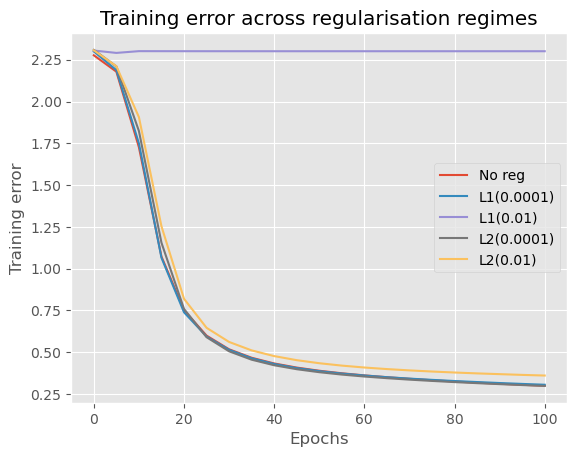

In [31]:
#Resuts for training error 

epochs = np.arange(0, 105, 5)

#TRAINING ERRORS 
exp1_train_errors = stats[:, 0]
exp2_train_errors = stats2[:, 0]
exp3_train_errors = stats3[:, 0]
exp4_train_errors = stats4[:, 0]
exp5_train_errors = stats5[:, 0]

fig, ax = plt.subplots()
ax.plot(epochs, exp1_train_errors, label = 'No reg')
ax.plot(epochs, exp2_train_errors, label = 'L1(0.0001)')
ax.plot(epochs, exp3_train_errors, label = 'L1(0.01) ')
ax.plot(epochs, exp4_train_errors, label = 'L2(0.0001)')
ax.plot(epochs, exp5_train_errors, label = 'L2(0.01)')

plt.xlabel('Epochs')
plt.ylabel('Training error')
plt.legend()
plt.title('Training error across regularisation regimes')
plt.show()

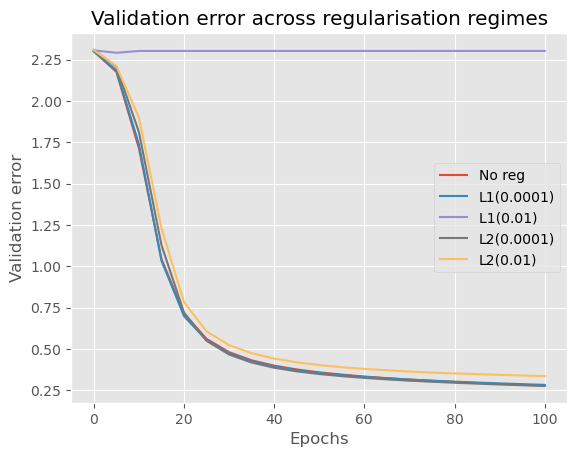

In [32]:
#Results for validation error 
#VALIDATION ERRORS
exp1_val_errors = stats[:, 2]
exp2_val_errors = stats2[:, 2]
exp3_val_errors = stats3[:, 2]
exp4_val_errors = stats4[:, 2]
exp5_val_errors = stats5[:, 2]

fig, ax = plt.subplots()
ax.plot(epochs, exp1_val_errors, label = 'No reg')
ax.plot(epochs, exp2_val_errors, label = 'L1(0.0001)')
ax.plot(epochs, exp3_val_errors, label = 'L1(0.01) ')
ax.plot(epochs, exp4_val_errors, label = 'L2(0.0001)')
ax.plot(epochs, exp5_val_errors, label = 'L2(0.01)')

plt.xlabel('Epochs')
plt.ylabel('Validation error')
plt.legend()
plt.title('Validation error across regularisation regimes')
plt.show()

## Weight Visualisation Analysis

The cells below define two functions for visualising the first layer weights of the trained models:

1. **`plot_param_histogram`**: Plots a histogram of weight values to show their distribution
2. **`visualise_first_layer_weights`**: Plots first layer weights as feature maps (28×28 images)

In the feature maps:
- **Red pixels** = negative weights  
- **Blue pixels** = positive weights
- **Grey pixels** = weights close to zero

---

## 🎯 **Your Task:**

Use these functions to create histogram and feature map visualisations for each trained model's first layer weights. 

**Analysis Questions:**
- How do L1 vs L2 regularisation affect the weight distributions?
- Which regularisation method produces more sparse weights (many zeros)?
- How do different penalty coefficients change the weight patterns?
- What do the learned feature maps reveal about each regularisation scheme?

In [34]:
import matplotlib.pyplot as plt

def plot_param_histogram(param, fig_size=(8, 4), interval=None):
    """Plots a normalised histogram of parameter values.
    
    Args:
        param: Array of parameter values to plot
        fig_size: Figure size as (width, height) tuple
        interval: Range for histogram bins as [min, max]. If None, uses data range.
    
    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    if interval is None:
        interval = [param.min(), param.max()]
        
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111)
    
    # Create histogram with 50 bins
    ax.hist(param.flatten(), bins=50, range=interval, density=True, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Parameter value')
    ax.set_ylabel('Normalised frequency density')
    ax.set_title('Distribution of Parameter Values')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    return fig, ax


def visualise_first_layer_weights(weights, fig_size=(8, 8)):
    """Plots a grid of first layer weights as feature maps.
    
    Each row of the weight matrix (corresponding to weights from input pixels 
    to a specific hidden unit) is visualised as a 28×28 image.
    
    Args:
        weights: First layer weight matrix of shape (n_hidden, 784)
        fig_size: Figure size as (width, height) tuple
        
    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    fig = plt.figure(figsize=fig_size)
    num_feature_maps = weights.shape[0]
    grid_size = int(num_feature_maps**0.5)
    
    # Create a tiled image to display all feature maps
    max_abs = np.abs(weights).max()
    tiled = -np.ones((30 * grid_size, 30 * num_feature_maps // grid_size)) * max_abs
    
    # Fill in each feature map
    for i, feature_map in enumerate(weights):
        row, col = i % grid_size, i // grid_size
        tiled[1 + row * 30:(row + 1) * 30 - 1, 
              1 + col * 30:(col + 1) * 30 - 1] = feature_map.reshape((28, 28))
    
    ax = fig.add_subplot(111)
    max_abs = np.abs(tiled).max()
    ax.imshow(tiled, cmap='RdBu_r', vmin=-max_abs, vmax=max_abs)
    ax.set_title('First Layer Weight Feature Maps')
    ax.axis('off')
    
    fig.tight_layout()
    plt.show()
    return fig, ax

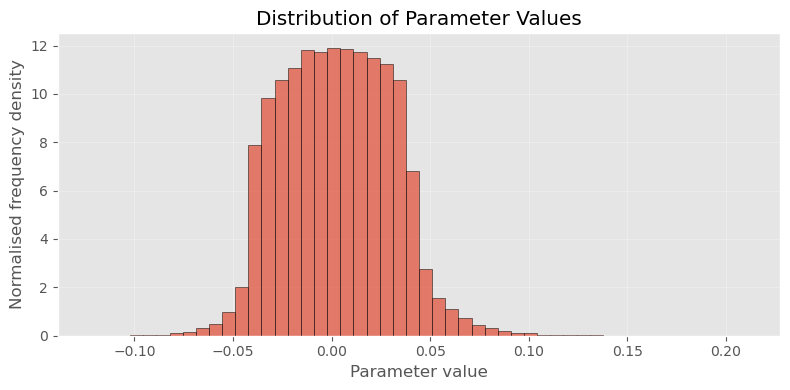

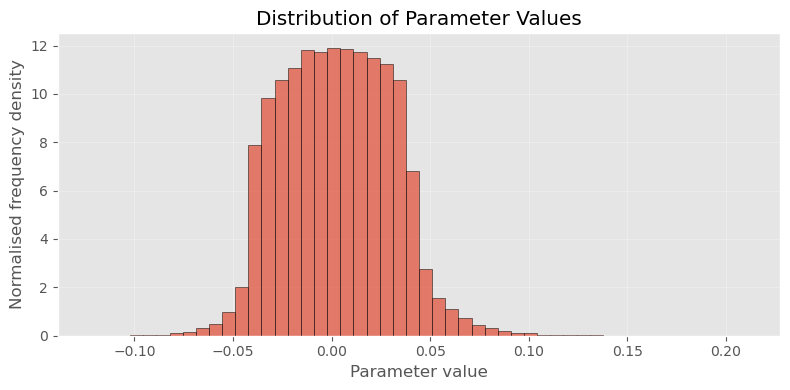

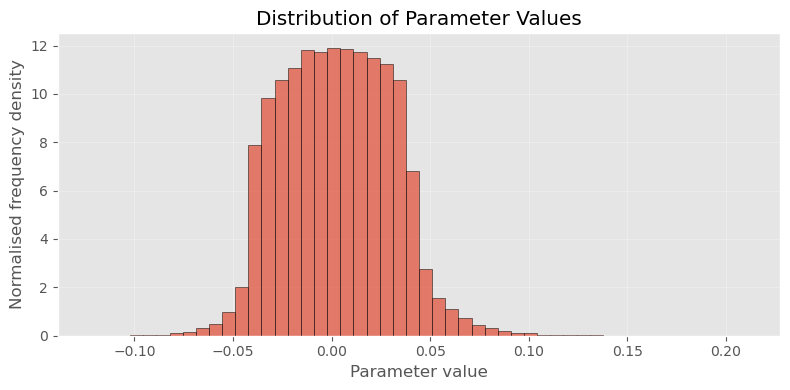

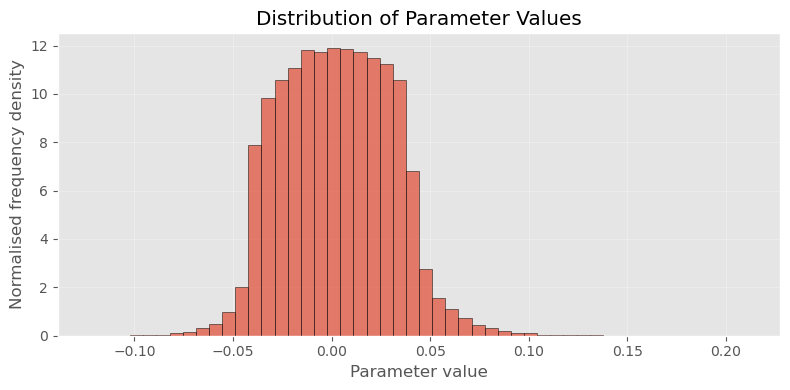

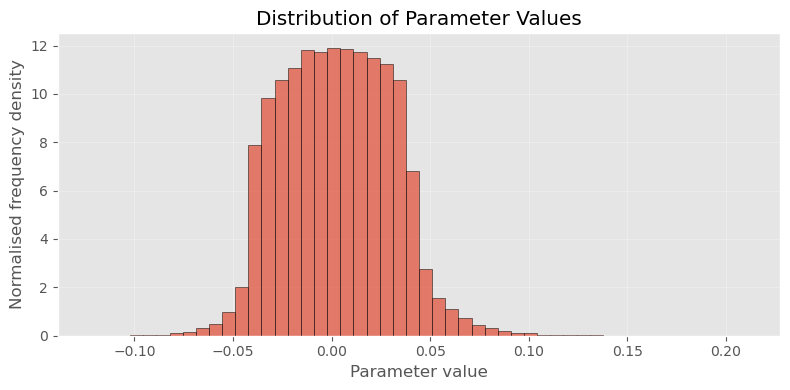

In [37]:
#TODO plot histogram and feature maps
weights = [layer_weights, layer_weights2, layer_weights3, layer_weights4, layer_weights5]

for layer_weight in weights: 
    plot_param_histogram(layer_weights)

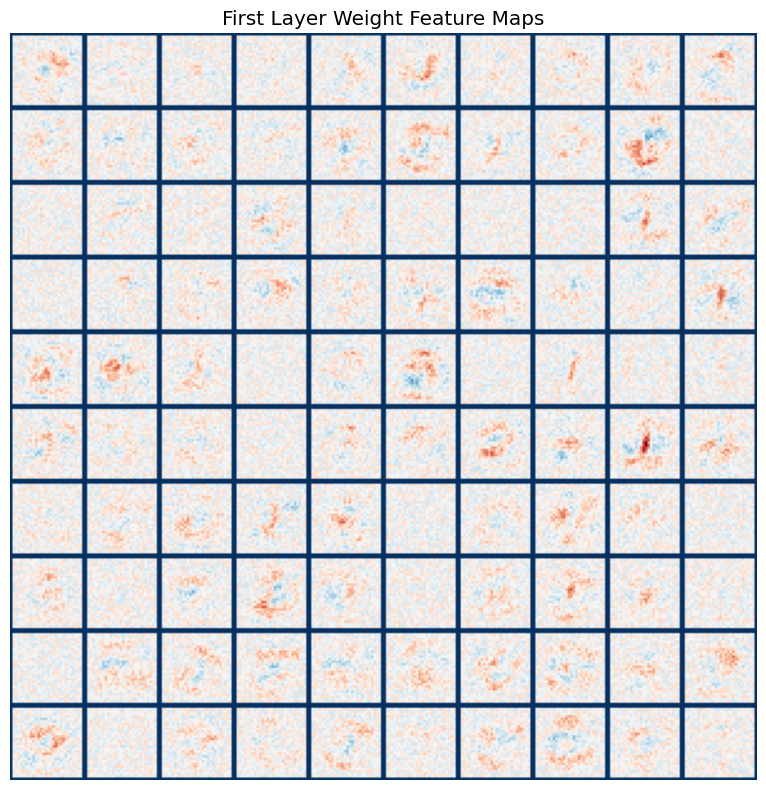

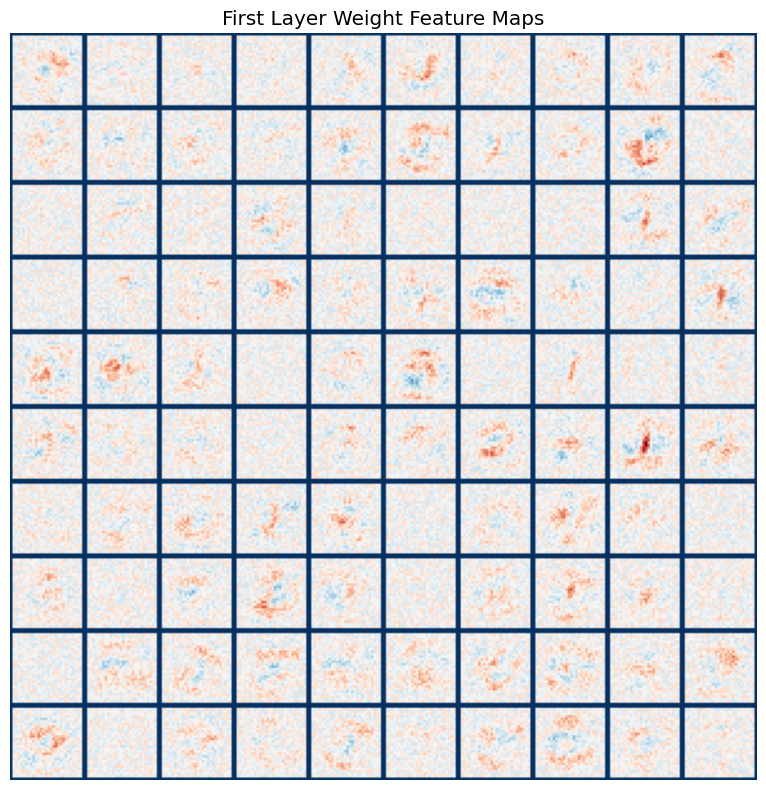

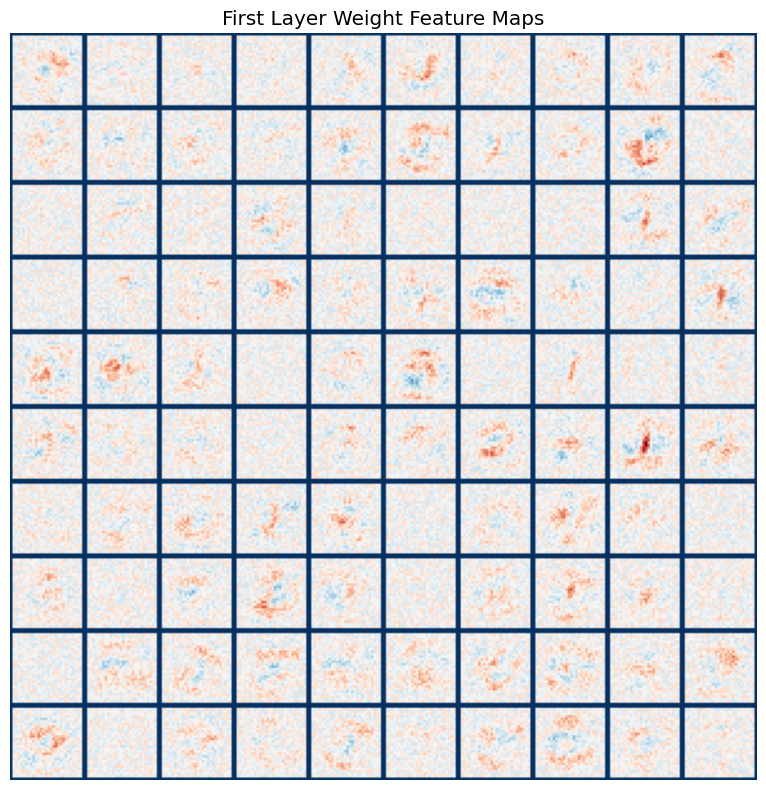

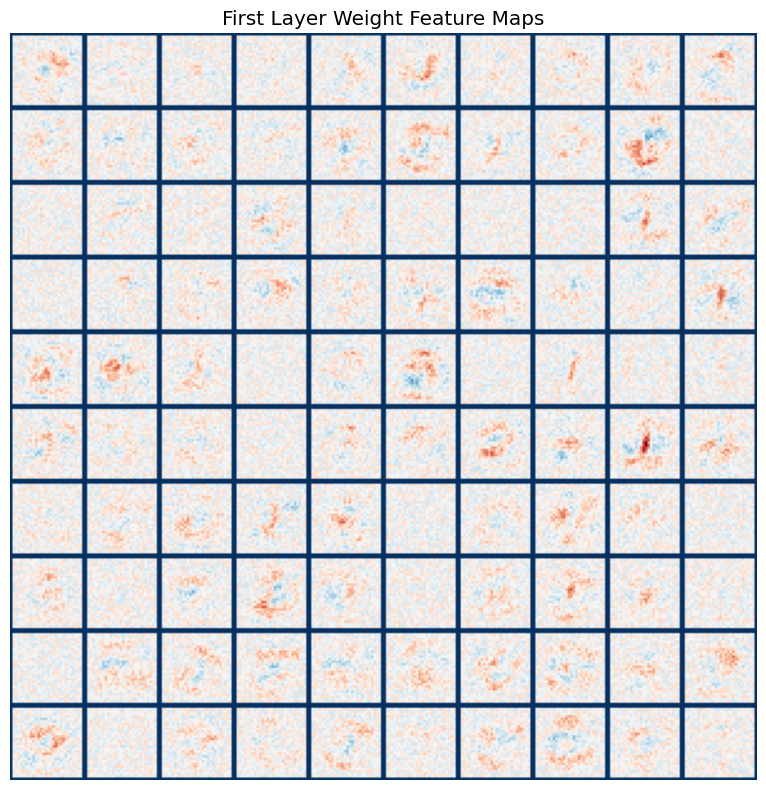

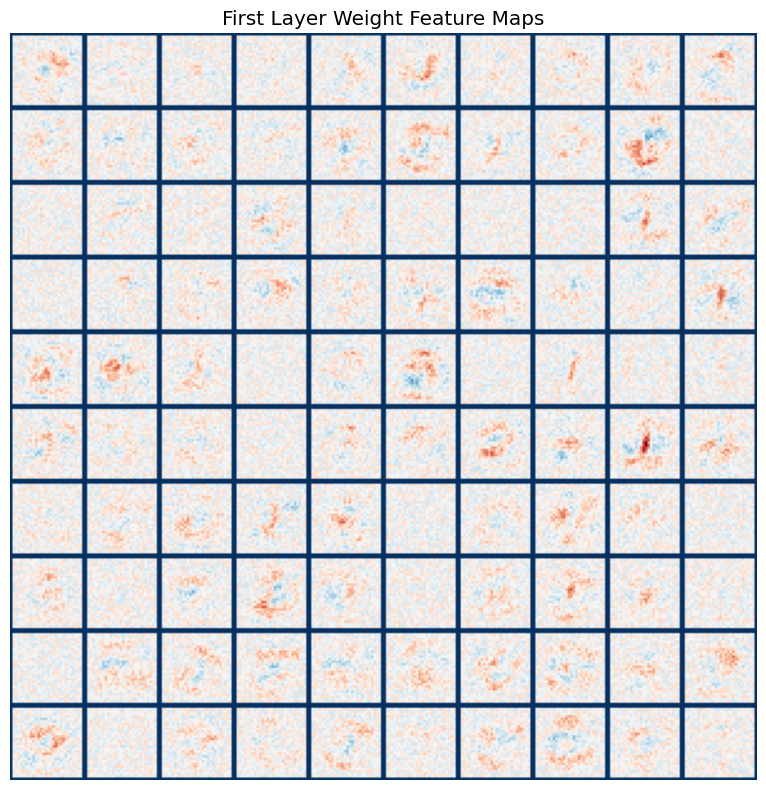

In [38]:
weights = [layer_weights, layer_weights2, layer_weights3, layer_weights4, layer_weights5]

for layer_weight in weights: 
    visualise_first_layer_weights(layer_weights)
    

# Exercise 3: Random Data Augmentation

Another technique for reducing overfitting is to artificially **augment the training dataset** by performing random transformations on the original training inputs. The idea is to generate additional artificial inputs that correspond to the same target class as the original input.

## Why Data Augmentation Works

The closer the artificially generated inputs appear to real inputs, the better, as they provide more realistic additional examples for the model to learn from. For handwritten digit images in MNIST, small rotations are a natural augmentation since:

- Small rotations don't change what we would identify as the digit class
- Real handwriting naturally varies in orientation
- This increases dataset diversity without changing labels

---

## 🎯 **Your Task:**

Implement a `random_rotation` function that:

### Requirements:
1. **Input**: A batch of MNIST images as 784-dimensional vectors (shape: `(batch_size, 784)`)
2. **Process**: 
   - Randomly select **25% of the images** in the batch
   - For each selected image, apply a **random rotation** between **-30° and +30°**
   - Leave the remaining 75% of images unchanged
3. **Output**: A new array of shape `(batch_size, 784)` with the rotated images

### Implementation Details:
- Use `scipy.ndimage.rotate` (imported below)
- Set `order=1` for bilinear interpolation (computational efficiency)
- Set `reshape=False` to maintain original image shape
- The original `inputs` array should **not** be modified

### Steps:
1. Reshape the 784-dimensional vectors back to 28×28 images
2. Randomly select 25% of the batch indices  
3. Generate random angles in [-30°, +30°] for selected images
4. Apply rotations to selected images
5. Reshape back to 784-dimensional vectors

**Hint**: Use `rng.choice()` for random selection and `rng.uniform()` for random angles.

In [ ]:
from scipy.ndimage import rotate

def random_rotation(inputs, rng):
    """Randomly rotates a subset of images in a batch.
    
    Args:
        inputs: Input image batch, an array of shape (batch_size, 784).
        rng: A seeded random number generator.
        
    Returns:
        An array of shape (batch_size, 784) corresponding to a copy
        of the original `inputs` array with the randomly selected
        images rotated by a random angle. The original `inputs`
        array should not be modified.
    """
    raise NotImplementedError("TODO Implement this function")

## Testing Your Implementation

Run the cell below to test your `random_rotation` function. This visualises a batch of images before and after applying the random rotation transformation using the `show_batch_of_images` function from Lab 1.

In [ ]:
from mlp.data_providers import MNISTDataProvider
import matplotlib.pyplot as plt

def show_batch_of_images(img_batch, fig_size=(8, 8)):
    """Display a batch of images in a grid layout.
    
    Args:
        img_batch: Array of shape (batch_size, height, width)
        fig_size: Figure size as (width, height) tuple
    """
    fig = plt.figure(figsize=fig_size)
    batch_size, im_height, im_width = img_batch.shape
    
    # Calculate grid dimensions (square grid)
    grid_size = int(batch_size**0.5)
    
    # Initialize empty array to tile image grid into
    tiled = np.empty((im_height * grid_size, 
                      im_width * batch_size // grid_size))
    
    # Tile images into grid
    for i, img in enumerate(img_batch):
        row, col = i % grid_size, i // grid_size
        tiled[row * im_height:(row + 1) * im_height, 
              col * im_width:(col + 1) * im_width] = img
    
    ax = fig.add_subplot(111)
    ax.imshow(tiled, cmap='Greys_r')  # Use Greys_r for better contrast
    ax.set_title('MNIST Images Grid')
    ax.axis('off')
    fig.tight_layout()
    plt.show()
    return fig, ax

# Test the random rotation function
print("Testing random_rotation function...")
test_data = MNISTDataProvider('test', 100, rng=rng)
inputs, targets = test_data.next()

print("Original images:")
_ = show_batch_of_images(inputs.reshape((-1, 28, 28)))

print("Images after random rotation (25% rotated):")
transformed_inputs = random_rotation(inputs, rng)
_ = show_batch_of_images(transformed_inputs.reshape((-1, 28, 28)))

print("Test completed! You should see that ~25% of images in the second grid are rotated.")

# Exercise 4: Training with Data Augmentation

## Static vs Dynamic Data Augmentation

### Static Augmentation
One approach is to pre-generate augmented data by applying transformations to the entire training dataset and storing both original and transformed examples. However, this has limitations:
- **Memory overhead**: Dataset size multiplies by the number of augmentations
- **Training time**: Longer epochs due to larger effective dataset size
- **Limited variety**: Fixed set of augmented examples

### Dynamic Augmentation (Recommended)
A better approach is to **randomly augment data on-the-fly** during training:
- **Memory efficient**: No need to store augmented data
- **Infinite variety**: Different augmentations every epoch
- **Computational trade-off**: Small overhead of applying transformations vs. memory savings

## Implementation with `AugmentedMNISTDataProvider`

The `AugmentedMNISTDataProvider` class in `mlp.data_providers` implements dynamic augmentation. It takes a `transformer` function that:
- Accepts an input batch array and random number generator
- Returns a randomly transformed version of the input batch

---

## 🎯 **Your Task:**

Train a model using dynamic data augmentation and compare it with your regularisation results.

### Model Configuration:
- **Same architecture** as Exercise 2 (3 layers, 100 hidden units, ReLU activations)
- **No L1/L2 regularisation** (to isolate the effect of data augmentation)
- **Data augmentation**: Use your `random_rotation` function as the transformer

### Training Parameters:
- All other hyperparameters should match Exercise 2
- Use `AugmentedMNISTDataProvider` for training data
- Use regular `MNISTDataProvider` for validation data

### Analysis:
Create plots comparing:
1. **Training error** over epochs (data augmentation vs all regularisation schemes)
2. **Validation error** over epochs (data augmentation vs all regularisation schemes)

### Expected Observations:
- How does data augmentation compare to L1/L2 regularisation?
- Does data augmentation help reduce overfitting?
- What are the trade-offs between data augmentation and parameter regularisation?

In [ ]:
from mlp.data_providers import AugmentedMNISTDataProvider

# Create augmented training data provider using our random_rotation function
aug_train_data = AugmentedMNISTDataProvider(
    'train', 
    rng=rng, 
    transformer=random_rotation
)

In [ ]:
#TODO train the model

In [ ]:
#TODO plot the results

# PyTorch Implementation

In this section, we'll implement L1 and L2 regularisation and data augmentation using **PyTorch**, a popular deep learning framework. This provides a practical comparison with the custom implementation above and demonstrates how regularisation is handled in modern deep learning libraries.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler

# Set random seed for reproducibility
seed = 12354
torch.manual_seed(seed)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available, using CPU")

In [ ]:
# Training configuration
batch_size = 128        # Larger batch size for PyTorch (GPU efficiency)
learning_rate = 0.001   # Lower learning rate typical for Adam optimizer
num_epochs = 100        # Same number of epochs
stats_interval = 5      # Print stats every 5 epochs

# Model architecture parameters
input_dim = 1 * 28 * 28  # MNIST images are 28x28 grayscale
output_dim = 10          # 10 digit classes (0-9)
hidden_dim = 100         # Same hidden dimension as custom implementation

print("PyTorch Training Configuration:")
print(f"- Batch size: {batch_size}")
print(f"- Learning rate: {learning_rate}")
print(f"- Hidden dimensions: {hidden_dim}")
print(f"- Device: {device}")

In [ ]:
# Data preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                    # Convert PIL image to tensor
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize with MNIST mean/std
])

# Download and load MNIST dataset
train_dataset = datasets.MNIST('../data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('../data', train=False, download=True, transform=transform)

# Create train/validation split (80/20)
valid_size = 0.2
num_train = len(train_dataset)
indices = list(range(num_train))
split = int(np.floor(valid_size * num_train))

# Shuffle indices for random split
np.random.seed(seed)  # Ensure reproducible split
np.random.shuffle(indices)

# Create train and validation index lists
train_idx, valid_idx = indices[split:], indices[:split]

print("Dataset splits:")
print(f"- Training samples: {len(train_idx)}")
print(f"- Validation samples: {len(valid_idx)}")
print(f"- Test samples: {len(test_dataset)}")

# Create samplers for train/validation split
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

In [ ]:
# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    sampler=train_sampler, 
    pin_memory=True
)

valid_loader = torch.utils.data.DataLoader(
    train_dataset,  # Use train_dataset with valid_sampler for validation
    batch_size=batch_size, 
    sampler=valid_sampler, 
    pin_memory=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    pin_memory=True
)

print("Data loaders created successfully!")
print(f"- Training batches: {len(train_loader)}")
print(f"- Validation batches: {len(valid_loader)}")
print(f"- Test batches: {len(test_loader)}")


class MultipleLayerModel(nn.Module):
    """PyTorch implementation of the multi-layer model.
    
    Equivalent to the model used in the custom implementation:
    - 3 fully connected layers
    - ReLU activations between layers
    - Same dimensions as custom implementation
    """
    
    def __init__(self, input_dim, output_dim, hidden_dim):
        super(MultipleLayerModel, self).__init__()
        
        # Flatten layer to convert 2D images to 1D vectors
        self.flatten = nn.Flatten()
        
        # Sequential model matching custom implementation architecture
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),   # First hidden layer
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  # Second hidden layer  
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),  # Output layer
        )
        
    def forward(self, x):
        """Forward pass through the network."""
        x = self.flatten(x)                    # Flatten to (batch_size, 784)
        logits = self.linear_relu_stack(x)     # Pass through layers
        return logits

# Create model instance
model = MultipleLayerModel(input_dim, output_dim, hidden_dim).to(device)

# Print model architecture
print("\nModel Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

## Regularisation in PyTorch

### L2 Regularisation (Weight Decay)

In PyTorch, L2 regularisation is typically implemented as **weight decay** in the optimizer. However, there's an important distinction:

- **True L2 regularisation**: Adds penalty term to loss function
- **Weight decay**: Applies decay directly to parameters during optimization

This difference matters when using optimizers with momentum:

1. **SGD without momentum**: Weight decay ≡ L2 regularisation  
2. **SGD with momentum**: Weight decay ≠ L2 regularisation
3. **Adam**: Uses weight decay (not equivalent to L2 regularisation)
4. **AdamW**: Implements "decoupled weight decay" as proposed by Loshchilov & Hutter

### L1 Regularisation

PyTorch doesn't have built-in L1 regularisation. We must manually add the L1 penalty to the loss function by:
1. Iterating through model parameters
2. Computing L1 norm of weight matrices (excluding biases)
3. Adding scaled penalty to the loss

In [ ]:
from collections import OrderedDict
# Define loss function
loss_fn = nn.CrossEntropyLoss()

# Define different optimizers to compare regularisation approaches
optimizers = OrderedDict([
    ("No Regularisation", optim.Adam(model.parameters(), lr=learning_rate)),
    ("SGD + L2 (weight_decay)", optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-3)),
    ("Adam + L2 (weight_decay)", optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)),
    ("AdamW + L2 (proper)", optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)),
    ("SGD + L1 (manual)", optim.SGD(model.parameters(), lr=learning_rate)),
    ("Adam + L1 (manual)", optim.Adam(model.parameters(), lr=learning_rate))
])

print("Optimizers configured:")
for name, optimizer in optimizers.items():
    print(f"- {name}")
print(f"\nTotal configurations to test: {len(optimizers)}")

### Manual L1 Regularisation Implementation

Since PyTorch doesn't provide built-in L1 regularisation, we implement it manually by accessing model parameters and computing the L1 penalty.

In [ ]:
def l1_penalty(model, l1_lambda=1e-3):
    """Compute L1 regularisation penalty for model parameters.
    
    Args:
        model: PyTorch model
        l1_lambda: L1 penalty coefficient
        
    Returns:
        L1 penalty term to add to loss
    """
    l1_norm = 0.0
    
    # Iterate through named parameters
    for name, param in model.named_parameters():
        # Only penalise weight matrices, not biases
        if 'weight' in name:
            l1_norm += torch.norm(param, p=1)  # L1 norm (sum of absolute values)
    
    return l1_lambda * l1_norm

# Test the L1 penalty function
print("Testing L1 penalty function:")
test_penalty = l1_penalty(model, l1_lambda=1e-3)
print(f"Current L1 penalty: {test_penalty.item():.6f}")

In [ ]:
losses = OrderedDict()

print("Starting PyTorch regularisation comparison...")
print("=" * 60)

for name, optimizer in optimizers.items():
    print(f'\nTraining model with: {name}')
    print("-" * 40)
    
    # Reinitialize model for fair comparison
    model = MultipleLayerModel(input_dim, output_dim, hidden_dim).to(device)
    
    # Update optimizer with new model parameters
    if "SGD" in name:
        if "L2" in name:
            optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-3)
        else:
            optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif "AdamW" in name:
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    elif "Adam" in name and "L2" in name:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    else:
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Track losses over training
    train_losses = []
    valid_losses = []
    
    # Training loop
    for epoch in range(num_epochs + 1):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_train_batches = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            # Forward pass
            output = model(data)
            loss = loss_fn(output, target)
            
            # Add L1 penalty for L1 regularisation methods
            if "L1" in name:
                loss += l1_penalty(model, l1_lambda=1e-3)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            num_train_batches += 1
        
        train_losses.append(epoch_train_loss / num_train_batches)
        
        # Validation phase
        model.eval()
        epoch_valid_loss = 0.0
        num_valid_batches = 0
        
        with torch.no_grad():
            for data, target in valid_loader:
                data, target = data.to(device), target.to(device)
                
                output = model(data)
                loss = loss_fn(output, target)
                
                # Add L1 penalty for consistency in validation loss
                if "L1" in name:
                    loss += l1_penalty(model, l1_lambda=1e-3)
                
                epoch_valid_loss += loss.item()
                num_valid_batches += 1
        
        valid_losses.append(epoch_valid_loss / num_valid_batches)
        
        # Print progress
        if epoch % stats_interval == 0:
            print(f'Epoch {epoch:3d}: Train Loss = {train_losses[-1]:.6f}, '
                  f'Valid Loss = {valid_losses[-1]:.6f}')
    
    # Store results
    losses[name] = (train_losses, valid_losses)
    
    print(f'Final - Train: {train_losses[-1]:.6f}, Valid: {valid_losses[-1]:.6f}')

print("\n" + "=" * 60)
print("PyTorch training completed!")
print("=" * 60)

# Data Augmentation in PyTorch

PyTorch implements data augmentation through the `torchvision.transforms` module, which provides:

- **Built-in transforms**: Ready-to-use transformations like rotation, scaling, cropping
- **Pipeline composition**: Chain multiple transforms together
- **GPU acceleration**: Some transforms can run on GPU
- **Automatic integration**: Seamlessly works with DataLoader

## Common Transforms for MNIST:
- `RandomRotation`: Random rotation within specified angle range
- `RandomAffine`: Combined rotation, translation, scaling, shearing  
- `RandomPerspective`: Perspective transformation
- `Normalize`: Standardization with dataset statistics

We'll implement both built-in transforms and a custom translation transform.

## Custom Transform: Translation

The `Translate` class below implements a custom data augmentation that randomly translates images in one of four directions. This demonstrates how to create custom PyTorch transforms.

**How it works:**
1. Generate random pixel shifts for each direction: `[shift_down, shift_up, shift_right, shift_left]`
2. Add padding in the chosen direction
3. Crop to maintain original image size

In [ ]:
class Translate:
    """Custom transform to randomly translate images.
    
    Translates the image by a random amount in one of four directions:
    down, up, right, left. The shift amount is randomly chosen between 0 and t pixels.
    """
    
    def __init__(self, max_shift):
        """Initialize the transform.
        
        Args:
            max_shift: Maximum number of pixels to shift in any direction
        """
        # Generate random shifts for [down, up, right, left]
        self.shifts = torch.randint(0, max_shift, (4,)).tolist()
        print(f"Translation shifts [down, up, right, left]: {self.shifts}")

    def __call__(self, img):
        """Apply random translation to the image.
        
        Args:
            img: Input image tensor of shape (C, H, W)
            
        Returns:
            Translated image of same shape as input
        """
        nchannels, nrows, ncols = img.shape
        
        for direction, shift_amount in enumerate(self.shifts):
            if shift_amount > 0:
                if direction == 0:  # Shift down
                    # Add padding at top, crop from bottom
                    pad = torch.zeros((nchannels, shift_amount, ncols))
                    img = torch.cat((pad, img), dim=1)  # Concatenate along height
                    img = img[:, :nrows, :ncols]        # Crop to original size
                    
                elif direction == 1:  # Shift up
                    # Add padding at bottom, crop from top
                    pad = torch.zeros((nchannels, shift_amount, ncols))
                    img = torch.cat((img, pad), dim=1)
                    img = img[:, shift_amount:, :ncols]
                    
                elif direction == 2:  # Shift right
                    # Add padding at left, crop from right
                    pad = torch.zeros((nchannels, nrows, shift_amount))
                    img = torch.cat((pad, img), dim=2)  # Concatenate along width
                    img = img[:, :nrows, :ncols]
                    
                elif direction == 3:  # Shift left
                    # Add padding at right, crop from left
                    pad = torch.zeros((nchannels, nrows, shift_amount))
                    img = torch.cat((img, pad), dim=2)
                    img = img[:, :nrows, shift_amount:]

        return img

print("Custom Translate transform defined successfully!")

In [ ]:
# Define augmented data transformation pipeline
augmented_transform = transforms.Compose([
    transforms.ToTensor(),                        # Convert to tensor
    transforms.Normalize((0.1307,), (0.3081,)),  # Normalize with MNIST stats
    Translate(10),                               # Custom translation (max 10 pixels)
    transforms.RandomRotation(20),               # Random rotation (±20 degrees)
])

# Create augmented datasets
train_dataset_aug = datasets.MNIST('../data', train=True, download=True, transform=augmented_transform)
test_dataset_aug = datasets.MNIST('../data', train=False, download=True, transform=augmented_transform)

print("Augmented datasets created with transforms:")
print("1. ToTensor() - Convert PIL to tensor")  
print("2. Normalize() - Zero mean, unit variance")
print("3. Translate(10) - Random translation up to 10 pixels")
print("4. RandomRotation(20) - Random rotation ±20 degrees")

# Create train/validation split for augmented data (same indices as before)
valid_size = 0.2
num_train = len(train_dataset_aug)
indices = list(range(num_train))
split = int(np.floor(valid_size * num_train))

# Use same random seed for consistent split
np.random.seed(seed)
np.random.shuffle(indices)

train_idx, valid_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

print(f"\nDataset splits (same as before):")
print(f"- Training samples: {len(train_idx)}")
print(f"- Validation samples: {len(valid_idx)}")

In [ ]:
# Create data loaders for augmented datasets
train_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug, 
    batch_size=batch_size, 
    sampler=train_sampler, 
    pin_memory=True
)

valid_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug,  
    batch_size=batch_size, 
    sampler=valid_sampler, 
    pin_memory=True
)

test_loader_aug = torch.utils.data.DataLoader(
    test_dataset_aug, 
    batch_size=batch_size, 
    shuffle=False, 
    pin_memory=True
)

print("Augmented data loaders created:")
print(f"- Training batches: {len(train_loader_aug)}")
print(f"- Validation batches: {len(valid_loader_aug)}")
print(f"- Test batches: {len(test_loader_aug)}")

## Visualizing Augmented Data

Let's examine what the augmented images look like after applying our transformations. This helps verify that the augmentations are reasonable and don't distort the images beyond recognition.

In [ ]:
# Visualize augmented images
print("Sampling augmented images for visualization...")

images_to_show = []
labels_to_show = []

# Get a few batches to show variety in augmentations
for i, (images, labels) in enumerate(test_loader_aug):
    if i >= 2:  # Only show first 2 batches
        break
    
    # Show first 5 images from each batch    
    for j in range(5):
        img = images[j].squeeze()  # Remove channel dimension for visualization
        label = labels[j].item()
        
        images_to_show.append(img)
        labels_to_show.append(label)
        
        # Create individual plot for each image
        plt.figure(figsize=(3, 3))
        plt.imshow(img, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

print(f"Displayed {len(images_to_show)} augmented images")
print("Notice the random rotations and translations applied to each image!")

In [ ]:
# Setup for data augmentation training
loss_fn = nn.CrossEntropyLoss()
model_aug = MultipleLayerModel(input_dim, output_dim, hidden_dim).to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=learning_rate)

print("Training model with data augmentation...")
print(f"Model parameters: {sum(p.numel() for p in model_aug.parameters())}")

In [ ]:
# Training with data augmentation
print("Starting training with data augmentation...")
print("-" * 50)

train_losses_aug = []
valid_losses_aug = []

for epoch in range(num_epochs + 1):
    # Training phase
    model_aug.train()
    epoch_train_loss = 0.0
    num_train_batches = 0
    
    for batch_idx, (data, target) in enumerate(train_loader_aug):
        data, target = data.to(device), target.to(device)
        
        # Forward pass
        output = model_aug(data)
        loss = loss_fn(output, target)
        
        # Backward pass and optimization
        optimizer_aug.zero_grad()
        loss.backward()
        optimizer_aug.step()
        
        epoch_train_loss += loss.item()
        num_train_batches += 1
    
    train_losses_aug.append(epoch_train_loss / num_train_batches)
    
    # Validation phase (without augmentation for fair comparison)
    model_aug.eval()
    epoch_valid_loss = 0.0
    num_valid_batches = 0
    
    with torch.no_grad():
        for data, target in valid_loader:  # Use non-augmented validation data
            data, target = data.to(device), target.to(device)
            
            output = model_aug(data)
            loss = loss_fn(output, target)
            
            epoch_valid_loss += loss.item()
            num_valid_batches += 1
    
    valid_losses_aug.append(epoch_valid_loss / num_valid_batches)
    
    # Print progress
    if epoch % stats_interval == 0:
        print(f'Epoch {epoch:3d}: Train Loss = {train_losses_aug[-1]:.6f}, '
              f'Valid Loss = {valid_losses_aug[-1]:.6f}')

# Store data augmentation results
losses["Data Augmentation"] = (train_losses_aug, valid_losses_aug)

print(f'\nFinal Results:')
print(f'Train Loss: {train_losses_aug[-1]:.6f}')
print(f'Validation Loss: {valid_losses_aug[-1]:.6f}')
print("Data augmentation training completed!")

In [ ]:
# Create comprehensive comparison plot for PyTorch results
fig = plt.figure(figsize=(16, 10))
ax1 = fig.add_subplot(2, 1, 1)
ax2 = fig.add_subplot(2, 1, 2)

# Plot all regularisation schemes and data augmentation
colors = plt.cm.tab10(np.linspace(0, 1, len(losses)))

for i, (name, (train_loss, valid_loss)) in enumerate(losses.items()):
    color = colors[i]
    linestyle = '--' if name == "Data Augmentation" else '-'
    linewidth = 3 if name == "Data Augmentation" else 2
    
    # Training losses
    ax1.plot(range(len(train_loss)), train_loss, 
             label=name, color=color, linestyle=linestyle, linewidth=linewidth)
    
    # Validation losses
    ax2.plot(range(len(valid_loss)), valid_loss, 
             label=name, color=color, linestyle=linestyle, linewidth=linewidth)

# Configure training loss plot
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('PyTorch: Training Loss Comparison')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Configure validation loss plot  
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.set_title('PyTorch: Validation Loss Comparison')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Print final comparison table
print("\n" + "="*80)
print("PYTORCH FINAL RESULTS SUMMARY")
print("="*80)
print(f"{'Method':<25} {'Final Train Loss':<18} {'Final Valid Loss':<18}")
print("-"*80)

for name, (train_loss, valid_loss) in losses.items():
    print(f"{name:<25} {train_loss[-1]:<18.6f} {valid_loss[-1]:<18.6f}")

print("="*80)
print("\n🎯 Key Observations:")
print("• Compare the effectiveness of different regularization approaches")
print("• Notice how weight decay behaves differently across optimizers")  
print("• Observe the impact of data augmentation vs parameter regularization")
print("• Consider computational trade-offs between methods")